Practical 1: The goal of this practical session is to build backprop from scratch and a small neural network (MLP).

Please return your notebook right at the end of the session.  You then have a week to return an updated version.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from graphviz import Digraph

In [3]:
# code to display a network - do not modify this cell
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    layer_colors = ["#FFCCCC", "#CCFFCC", "#CCCCFF", "#FFCC99", "#99CCFF"]

    def get_color(node):
        if node._op == '+': return layer_colors[0]
        elif node._op == '*': return layer_colors[1]
        elif node._op == 'tanh': return layer_colors[2]
        # Ajoutez d'autres conditions ici pour d'autres opérations ou couches
        return layer_colors[-1]  # Couleur par défaut

    for n in nodes:
        color = get_color(n)
        dot.node(name=str(id(n)), label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record', style='filled', fillcolor=color)
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [4]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other): # TODO: ex.1
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), _op='+')

    def _backward(): # ex. 4
      self.grad = 1.0 * out.grad # BUG
      other.grad = 1.0 * self.grad
    out._backward = _backward

    return out

  def __mul__(self, other): # TODO: ex.1
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward(): # ex. 4
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other): # ex. 6
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

 # Ex 1

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

# Ex 3
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    # Ex 4
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def relu(self):
    eps = .1
    t = self.data if self.data > 0 else self.data * eps
    out = Value(t, (self,), 'relu')

    def _backward():
      self.grad += out.grad if self.data > 0 else eps * out.grad
    out._backward = _backward
    return out

  # Ex 6
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [5]:
# Exercise 1: fill in __add__ and __mul__ in the Value class to enable the following function. You should get -8.0 as a result.
def lol():

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    return L

print(lol().data)

-8.0


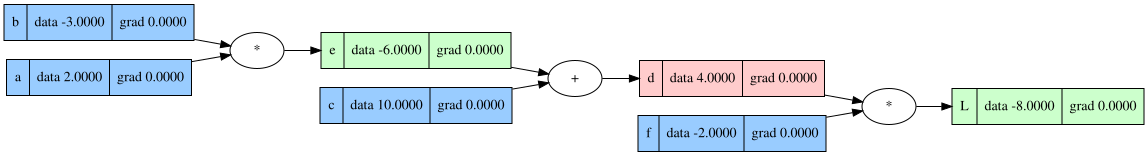

In [6]:
draw_dot(lol())

In [7]:
# Exercise 2: use the lol_grad() function below to manually compute dL/df, dL/dd, dL/de, dL/dc, dL/da, dL/db
def lol_grad():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    d += h
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L2 = L.data

    print("dl/dd = ",(L2-L1)/h)

    #dl/df

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    f += h
    L = d*f; L.label='L'
    Lf = L.data

    print("dl/df = ",(Lf-L1)/h)

    # dl/de
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    e+= h
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    Le = L.data

    print("dl/de = ",(Le-L1)/h)

    # dl/dc

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    c += h
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    Lc = L.data

    print("dl/dc = ",(Lc-L1)/h)

    # dl/da

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    a += h
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    La = L.data

    print("dl/da = ",(La-L1)/h)

    # dl/db

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b += h
    c = Value(10.0, label='c')
    a += h
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    Lb = L.data

    print("dl/db = ",(Lb-L1)/h)

In [8]:
# report the values for dL/df, dL/dd, dL/de, dL/dc, dL/da, dL/db in this cell
# dl/dd = -2.0
# dL/df = 4.0
# dl/de = -2.0
# dl/dc = -2.0
# dl/da = 6.0
# dl/db = 2.0

lol_grad()


dl/dd =  -1.9999999999953388
dl/df =  3.9999999999995595
dl/de =  -1.9999999999953388
dl/dc =  -1.9999999999953388
dl/da =  6.000000000021544
dl/db =  1.9997999999965543


In [9]:
# Exercise 3: implement the function tanh() in the Value class and build the following network
# input
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.7, label='b')
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1z2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


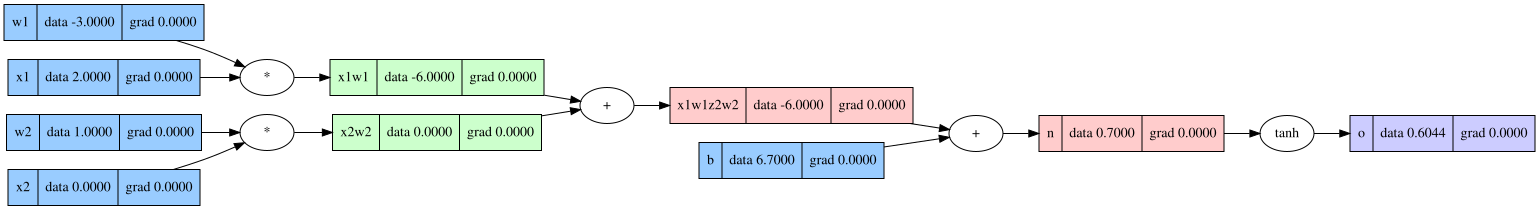

In [10]:
# o.data should be 0.6044
draw_dot(o)

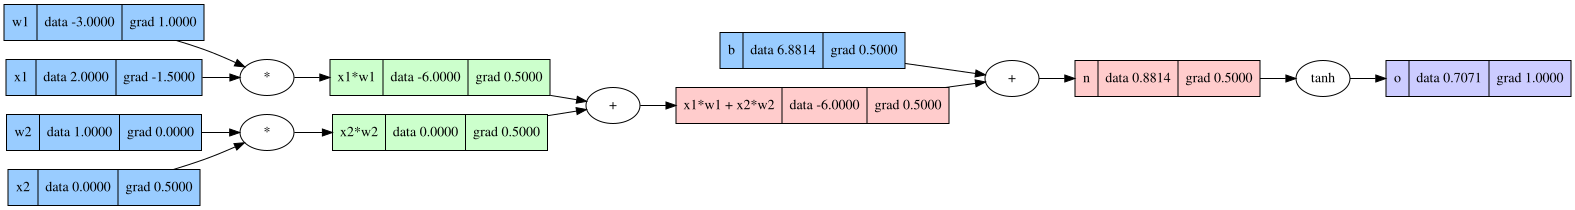

In [11]:
# Exercise 4: Implement the backward() function in each Value's operator: __add__, __mul__, __tanh__ and assign it to _backward
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
#e = (2*n).exp()
#o = (e - 1) / (e + 1)
o = n.tanh()
# ----
o.label = 'o'
o.backward()
draw_dot(o)

 # expected results:
 # o.data should be 0.7071
 # w1.grad = 1.0
 # w2.grad = 0.0
 # x1.grad = -1.5
 # x2.grad = 0.5

In [12]:
# Exercise 5: why are we using self.grad += and not self.grad = in the backward() functions?  Answer as a comment in this cell.
# Hint: create a Value "a" and then b = a + a. What happens when you do b.backward()?

# We use "self.grad += ..." in backward functions because a variable can contribute to the output via multiple paths in the computational graph.
# Hence, its total gradient is the sum of gradients from all paths. For instance, if a Value "a" is used twice in the computation, then in "b = a + a", b.backward() will accumulate gradients in a.grad from both contributions.

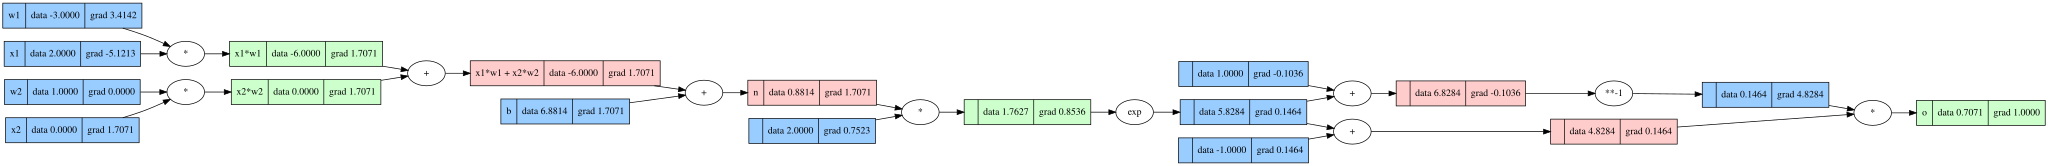

In [13]:
# Exercise 6: replace the tanh() function by a combination of exp() and division.  Implement the __exp__ and __pow__ functions in Value. You should get the same results as before.
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
#o = ... (no tanh allowed)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [14]:
# Congratulations!  You "unlocked" the basic layer of pytorch.  Now you know what happens under the hood of the following code. Check that you get the same output as before for grad values.

import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())


0.7071066904050358
---
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


In [15]:
# Exercise 7: Let's build an MLP based on the Value class.  Fill in the Neuron, Layer and MLP classes.

In [16]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.relu()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [17]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.5152723640134286)

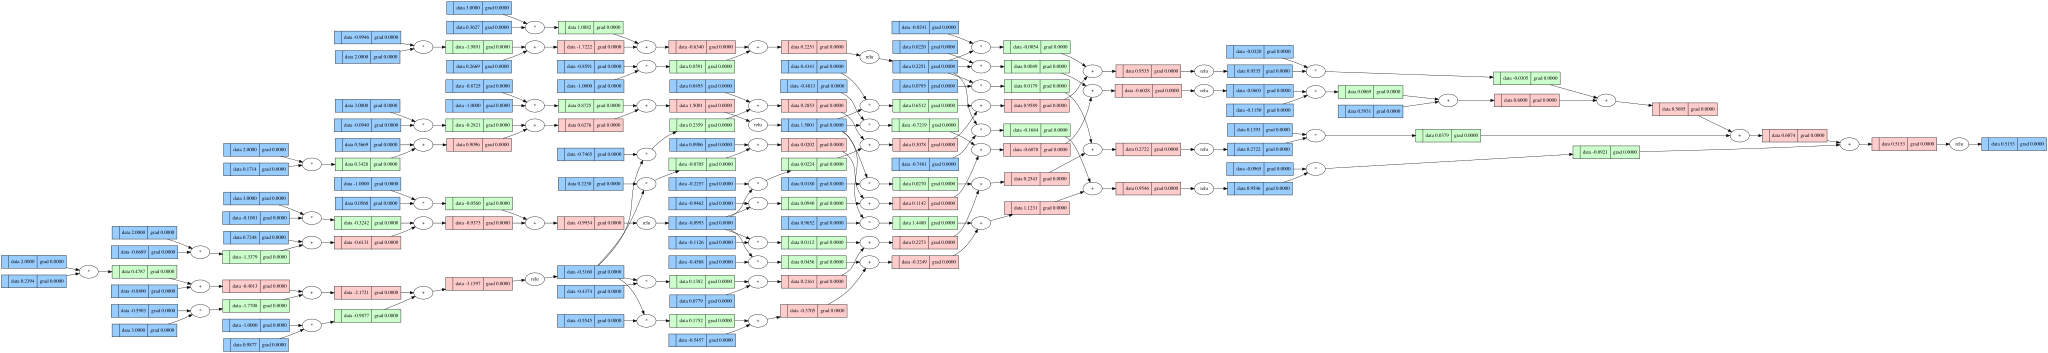

In [18]:
draw_dot(n(x))

In [19]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [20]:
len(n.parameters())

41

In [21]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.5152723640134286),
 Value(data=0.5849354048424376),
 Value(data=0.6089012257925569),
 Value(data=0.5416130007287676)]

In [22]:
loss = sum([(a-b)**2 for (a,b) in zip(ypred, ys)])
loss

Value(data=5.545662914069869)

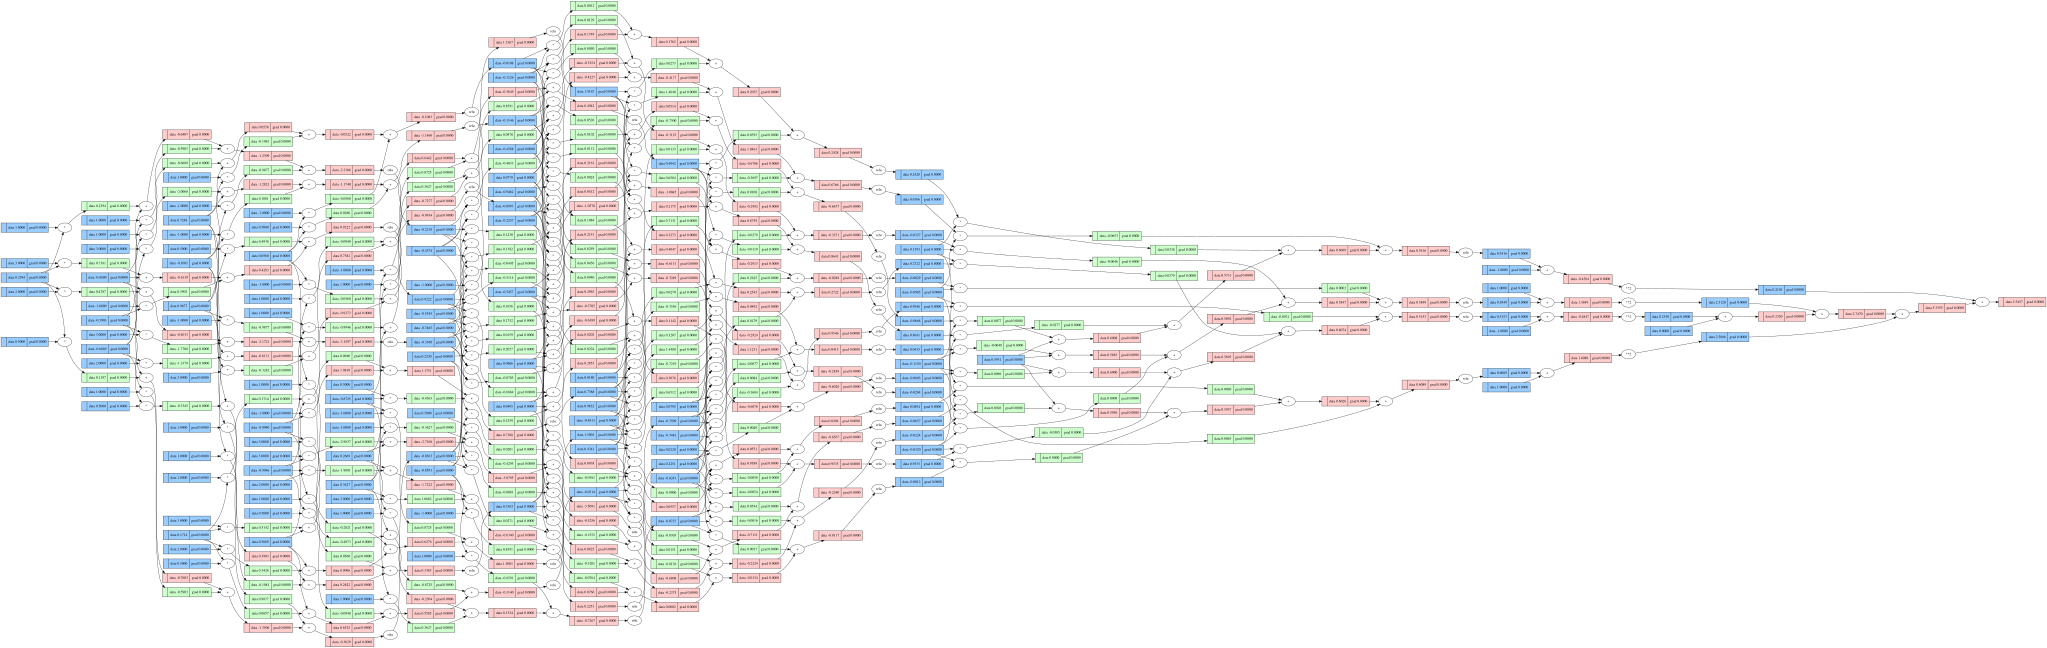

In [23]:
# see how a simple MLP can yield a complex graph already
draw_dot(loss)

In [24]:
# Exercise 8: write a training loop
# Answer
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(a-b)**2 for(a,b) in zip(ypred, ys)])

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad
    print(k, loss.data)

0 5.545662914069869
1 5.608908749057657
2 5.446481467417214
3 4.882688232402101
4 3.8923476958692778
5 2.969037091566335
6 2.9310869388263194
7 2.819850858268482
8 2.1349760891025493
9 2.409943258960731
10 2.7666866911955488
11 2.2942433316387274
12 2.2006088488940283
13 2.1529382521116283
14 2.133060276485217
15 2.0617533678200477
16 2.055520783997921
17 1.5554107171491367
18 1.573488905106493
19 1.6545530044619803


In [25]:
# Exercise 9: why do you need to reset the grads to zero at every training step?  Answer as a comment in this cell.

# We reset gradients at every training step because gradients in our autograd system accumulate by default
# If we did not zero them out, then gradients from previous steps would be added to the current step, leading to incorrect updates.

In [ ]:
num = 100
xs = [[a/num] for a in range(-num, num)]
ys = [b[0]**2 for b in xs]
n = MLP(1,[8,8,1])
len(n.parameters())

for k in range(200):
    # forward pass (compute the loss)
    ypred = [n(x) for x in xs]
    loss = sum([(a-b)**2 for(a,b) in zip(ypred, ys)])

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.001 * p.grad
    print(k, loss.data)

In [26]:
# Exercise 10 (*): try to approximate the n^2 function with a 2-layer MLP.  why is it so hard?

num = 100
xs = [[a/num] for a in range(-num, num)]
ys = [b[0]**2 for b in xs]
n = MLP(1,[8,8,1])
len(n.parameters())

for k in range(200):
    # forward pass (compute the loss)
    ypred = [n(x) for x in xs]
    loss = sum([(a-b)**2 for(a,b) in zip(ypred, ys)])
    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    # update
    for p in n.parameters():
        p.data += -0.001 * p.grad
    print(k, loss.data)


0 49.55654135149949
1 47.055044474618434
2 41.9609066749017
3 27.24587990409795
4 15.634442891164083
5 7.104384164995097
6 19.779161623835716
7 10.387189001459681
8 25.533792405379224
9 2.410970141634145
10 3.3341910110984037
11 4.625007230831068
12 8.982975265734808
13 9.098466819217682
14 19.59925973404241
15 4.972040179262135
16 8.54233899626358
17 7.039952036630624
18 12.813371739326334
19 6.530864790208335
20 10.920299540341052
21 6.126064560064115
22 9.508205106676556
23 5.63423909905956
24 8.09220224375337
25 4.915744015580319
26 6.440546701480929
27 4.260511518624775
28 5.136115898455813
29 3.709739223147186
30 4.27809092098636
31 3.182862398105222
32 3.508274543733819
33 2.7142804777143867
34 2.895590107738
35 2.3208785845560094
36 2.3929287109366624
37 1.9563360233930276
38 1.9634698853502932
39 1.6329443193441198
40 1.6042645205351593
41 1.3933584948694684
42 1.356466692559472
43 1.1545228155662828
44 1.1134862905562273
45 0.9861074108087794
46 0.9574922250302376
47 0.871274

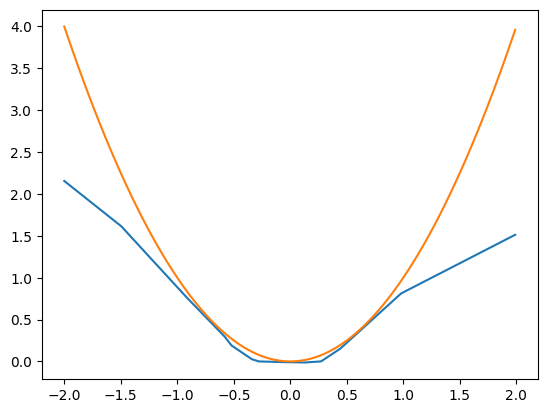

In [27]:
xs = [a/100 for a in range(-200,200)]
ys = [n([x]).data for x in xs]
yg = [x**2 for x in xs]
plt.plot(xs, ys)
plt.plot(xs, yg)
plt.show()


In [28]:
# Comparison with tanH

In [29]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh() # change ReLu to tanh
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [30]:
num = 100
xs = [[a/num] for a in range(-num, num)]
ys = [b[0]**2 for b in xs]
n = MLP(1,[8,8,1])
len(n.parameters())

for k in range(200):
    # forward pass (compute the loss)
    ypred = [n(x) for x in xs]
    loss = sum([(a-b)**2 for(a,b) in zip(ypred, ys)])
    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    # update
    for p in n.parameters():
        p.data += -0.001 * p.grad
    print(k, loss.data)

0 131.5021304577445
1 84.74039826622604
2 54.66915138688815
3 35.81625579033039
4 25.656916823062698
5 19.485305308334826
6 15.948088368350161
7 14.015672228225597
8 12.942012846676066
9 12.301102346036147
10 11.877176615344144
11 11.544937096672873
12 11.260076932951971
13 11.003182073954282
14 10.754152419945385
15 10.517856885214968
16 10.278776302697548
17 10.041788537353932
18 9.80809956502239
19 9.581810149191183
20 9.352055703499786
21 9.129970229089867
22 8.905015272959055
23 8.681308199873884
24 8.463777696315459
25 8.245785797413872
26 8.029939534625248
27 7.822239153406946
28 7.612612890516391
29 7.406218731876533
30 7.207546068389395
31 7.007653041054568
32 6.815354033923849
33 6.622309844258363
34 6.4323931152645235
35 6.250128934646582
36 6.068620116367526
37 5.893819004909575
38 5.720368611488177
39 5.550530029328638
40 5.385217388101009
41 5.22415598892454
42 5.06759930545363
43 4.918700671959057
44 4.771169121963405
45 4.630668884841105
46 4.491858166636157
47 4.356847

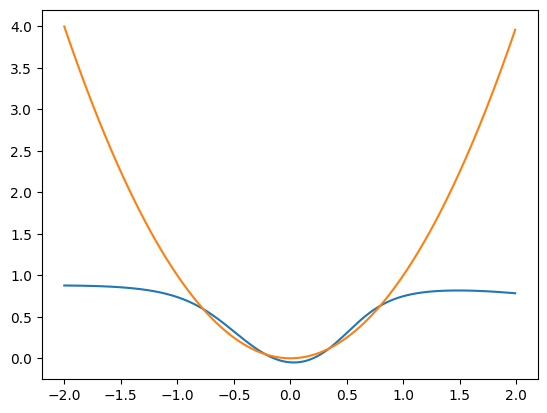

In [32]:
xs = [a/100 for a in range(-200,200)]
ys = [n([x]).data for x in xs]
yg = [x**2 for x in xs]
plt.plot(xs, ys)
plt.plot(xs, yg)
plt.show()


In [31]:
# Approximating the n^2 function is challenging because the nonlinearity (tanh or ReLU) and the network’s capacity may be insufficient to capture the curvature of the quadratic function, particularly in small networks.
# In this exercise, the output is constrained to a maximum of 1 due to the tanh activation function. As a result, the model fails to learn the square function when x is outside the range [0,1].
# This type of network is generally better suited for approximating linear functions or smoother transformations. The main challenge lies in the fact that the tanh activation enforces bounded outputs, and a simple neural network struggles to capture quadratic interactions without a sufficient number of neurons or layers.